In [1]:
using HDF5
using PyPlot
using ProgressBars
using JLD2
using Images, ImageFiltering
using Statistics
import PhysicalConstants.CODATA2018: c_0, ħ
using Unitful

In [2]:
function load_imgs(filenames, pathdir)
    imgs_atoms, imgs_bkg, imgs_dark, intensities = [], [], [], []

    for filename in filenames
        filename = pathdir*filename
        h5open(filename, "r") do file
            img_atoms = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/atoms"]))
            img_bkg = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/background"]))
            img_dark = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/dark"]))
            push!(imgs_atoms, img_atoms), push!(imgs_bkg, img_bkg), push!(imgs_dark, img_dark), push!(intensities, read_attribute(file["globals"], "vert_abs_img_amp_high"))
        end
    end
    return imgs_atoms, imgs_bkg, imgs_dark, intensities
end

function crop_imgs(imgs, x_crop, y_crop, mask)
    imgs_crop = []
    for i = 1:length(imgs)
        img_crop = imgs[i][y_crop, x_crop]
        push!(imgs_crop, img_crop .* mask)
    end
    return imgs_crop
end

function compute_OD_high_low_intensity(imgs_atoms, imgs_bkg, imgs_dark, dict_set_val_sat, intensities_imgs, t_exp)
    ODs = []
    for i in 1:length(imgs_atoms)
        OD = (imgs_atoms[i] .- imgs_dark[i]) ./ (imgs_bkg[i] .- imgs_dark[i])

        OD[OD .< 0] .= NaN # Values where dark is brighter than laser/atoms are not taken into account
        OD .= -log10.(OD)
        OD[isnan.(OD)] .= 0 # Map Nan values to 0

        # For high intensity, modified OD formula
        if dict_set_val_sat[intensities_imgs[i]] >= 1
            OD .+= (imgs_bkg[i] .- imgs_atoms[i]) / (7000*t_exp[findfirst(==(intensities_imgs[i]), I_set_value)]/5e-6)
        end
        push!(ODs, OD)
    end
    return ODs
end

function mask_ellipse(xc, yc, a, b, θ, x_crop, y_crop)
    mask = zeros(Integer, (length(y_crop), length(x_crop)))
    X = range(0, length(y_crop)-1) .- yc
    Y = range(0, length(x_crop)-1) .- xc
    for (i, x) in enumerate(X)
        for (j, y) in enumerate(Y)
            # Rotate back
            x_hor = x*sin(θ) + y*cos(θ)
            y_hor = x*cos(θ) - y*sin(θ)
            if (x_hor/a)^2 + (y_hor/b)^2 ≤ 1
                mask[i, j] = 1
            end
        end
    end
    return mask
end

function smooth_imgs(img, size_kernel)
    flat_kernel = ones(size_kernel, size_kernel)/size_kernel^2
    img_smooth = imfilter(img, flat_kernel)
    return img_smooth
end

function normalize(img)
    img_norm = (img .- minimum(img)) ./ (maximum(img)-minimum(img))
    return img_norm
end

function find_droplets_radius_range(img, droplet_radius_range, threshold_droplets_range)
    blob_centers = []
    response = zeros(size(img))

    for droplet_radius in droplet_radius_range
        log_kernel = Kernel.gaussian(droplet_radius)
        response .+= imfilter(img, log_kernel)
        response = response .* droplet_radius^2
    end
    
    blobs = response .> threshold_droplets_range *std(img)^(1/2) # Adaptative threshold depending on the std of the img

    label_blobs = label_components(blobs) # Separate the blobs
    for label in 1:maximum(label_blobs) # Find the center of each blob
        inds = findall(label_blobs .== label)
        push!(blob_centers, [mean([i[2]-1 for i in inds]), mean([i[1]-1 for i in inds])])
    end

    return blob_centers, label_blobs
end

find_droplets_radius_range (generic function with 1 method)

In [3]:
pathdir = "//DyLabNAS/Data/TwoDGas/2025/07/04"
dir_names_datasets = readdir(pathdir)
dir_names_datasets = dir_names_datasets[dir_names_datasets .!= ".DS_Store"]
dir_names_datasets = dir_names_datasets[10:end]

I_set_value = [0.1882, 0.22, 0.35, 0.6, 0.8, 1.0]
sat_exp = [0.5, 1, 5, 32, 56, 65] # Estimated saturation parameter
dict_set_val_sat = Dict(I_set_value[i] => sat_exp[i] for i in eachindex(I_set_value))

τ_exp = [8, 7, 6, 5, 3, 2].*1e-6
x_crop = [1290:1560;]
y_crop = [1840:2210;]
wrong_shots = []
λ = 421e-9
ω0 = 2π*ustrip(c_0)/λ
γ = 32.7e6 # In Hz
I_sat_cst = ustrip(ħ)*γ*ω0^3 / (12π*ustrip(c_0)^2)

N_atoms_per_droplet = 15000
radius_droplets = 14 # In pxls

xc, yc, a, b, θ = 140, 200, 70, 40, 1.1;

In [4]:
if !isdir("imgs")
    mkdir("imgs")
end

if !isdir("imgs/"*join(split(pathdir, "/")[6:end], "_"))
    mkdir("imgs/"*join(split(pathdir, "/")[6:end], "_"))
end

if !isdir("imgs/"*join(split(pathdir, "/")[6:end], "_")*"/ODs_mask")
    mkdir("imgs/"*join(split(pathdir, "/")[6:end], "_")*"/ODs_mask")
end

if !isdir("imgs/"*join(split(pathdir, "/")[6:end], "_")*"/neg_ODs_mask")
    mkdir("imgs/"*join(split(pathdir, "/")[6:end], "_")*"/neg_ODs_mask")
end

if !isdir("imgs/"*join(split(pathdir, "/")[6:end], "_")*"/droplets")
    mkdir("imgs/"*join(split(pathdir, "/")[6:end], "_")*"/droplets")
end

# Import and crop the images

In [5]:
imgs_atoms_crop_datasets, imgs_bkg_crop_datasets, imgs_dark_crop_datasets, intensities_imgs_datasets = [], [], [], []
mask = mask_ellipse(xc, yc, a, b, θ, x_crop, y_crop)

for dir_name_datasets in ProgressBar(dir_names_datasets)
    files_path = readdir(pathdir*"/"*dir_name_datasets)
    imgs_atoms, imgs_bkg, imgs_dark, intensities_imgs = load_imgs(files_path, pathdir*"/"*dir_name_datasets*"/")
    imgs_atoms_crop, imgs_bkg_crop, imgs_dark_crop = crop_imgs(imgs_atoms, x_crop, y_crop, mask), crop_imgs(imgs_bkg, x_crop, y_crop, mask), crop_imgs(imgs_dark, x_crop, y_crop, mask)
    push!(imgs_atoms_crop_datasets, imgs_atoms_crop), push!(imgs_bkg_crop_datasets, imgs_bkg_crop), push!(imgs_dark_crop_datasets, imgs_dark_crop), push!(intensities_imgs_datasets, intensities_imgs)
end

0.0%┣                                                ┫ 0/6 [00:01<00:-8, -1s/it]
16.7%┣███████▏                                   ┫ 1/6 [00:42<Inf:Inf, InfGs/it]
33.3%┣███████████████▊                               ┫ 2/6 [01:20<05:19, 80s/it]
50.0%┣███████████████████████▌                       ┫ 3/6 [01:59<02:59, 60s/it]
66.7%┣███████████████████████████████▍               ┫ 4/6 [02:40<01:47, 53s/it]
83.3%┣███████████████████████████████████████▏       ┫ 5/6 [03:24<00:51, 51s/it]
100.0%┣██████████████████████████████████████████████┫ 6/6 [04:09<00:00, 50s/it]
100.0%┣██████████████████████████████████████████████┫ 6/6 [04:09<00:00, 50s/it]


In [6]:
# Vcat so that they have the same shape as Chrichri
imgs_atoms_crop_datasets, imgs_bkg_crop_datasets, imgs_dark_crop_datasets, intensities_imgs = vcat(imgs_atoms_crop_datasets...), vcat(imgs_bkg_crop_datasets...), vcat(imgs_dark_crop_datasets...), vcat(intensities_imgs_datasets...);

In [7]:
@save "Imgs_crop_mask_"*join(split(pathdir, "/")[3:end], "_")*".jld2" imgs_atoms_crop_datasets imgs_bkg_crop_datasets imgs_dark_crop_datasets intensities_imgs

In [4]:
@load "Imgs_crop_mask_"*join(split(pathdir, "/")[3:end], "_")*".jld2" imgs_atoms_crop_datasets imgs_bkg_crop_datasets imgs_dark_crop_datasets intensities_imgs;

# Compute the ODs

In [30]:
ODs_dataset = compute_OD_high_low_intensity(imgs_atoms_crop_datasets, imgs_bkg_crop_datasets, imgs_dark_crop_datasets, dict_set_val_sat, intensities_imgs, τ_exp);

In [31]:
@save "ODs_crop_mask"*join(split(pathdir, "/")[3:end], "_")*".jld2" ODs_dataset

In [5]:
@load "ODs_crop_mask"*join(split(pathdir, "/")[3:end], "_")*".jld2" ODs_dataset;

# Save the ODs images

### ODs

In [33]:
close("all")
fig, axs = subplots()

for (i, OD) in ProgressBar(enumerate(ODs_dataset))
    img = axs.imshow(OD, cmap="plasma") #, aspect="auto"
    cb = colorbar(img)
    savefig("imgs/"*join(split(pathdir, "/")[6:end], "_")*"/ODs_mask/"*"$(i-1).png")
    cb.remove()
    axs.clear()
end
close("all")

0.0%┣                                              ┫ 0/300 [00:00<00:00, -0s/it]
0.3%┣▏                                         ┫ 1/300 [00:00<Inf:Inf, InfGs/it]
0.7%┣▎                                              ┫ 2/300 [00:00<01:29, 3it/s]
1.0%┣▌                                              ┫ 3/300 [00:00<01:05, 5it/s]
1.3%┣▋                                              ┫ 4/300 [00:01<00:56, 5it/s]
1.7%┣▉                                              ┫ 5/300 [00:01<00:51, 6it/s]
2.0%┣█                                              ┫ 6/300 [00:01<00:48, 6it/s]
2.3%┣█                                              ┫ 7/300 [00:01<00:46, 6it/s]
2.7%┣█▎                                             ┫ 8/300 [00:01<00:44, 7it/s]
3.0%┣█▍                                             ┫ 9/300 [00:01<00:43, 7it/s]
3.3%┣█▌                                            ┫ 10/300 [00:01<00:43, 7it/s]
3.7%┣█▊                                            ┫ 11/300 [00:01<00:42, 7it/s]
4.0%┣█▉                     

### Negative ODs

In [34]:
close("all")
fig, axs = subplots()

for (i, OD) in ProgressBar(enumerate(ODs_dataset))
    img = axs.imshow(OD, cmap="bone", vmin=-0.2, vmax=0) #, aspect="auto"
    cb = colorbar(img)
    savefig("imgs/"*join(split(pathdir, "/")[6:end], "_")*"/neg_ODs_mask/"*"$(i-1).png")
    cb.remove()
    axs.clear()
end
close("all")

0.0%┣                                              ┫ 0/300 [00:00<00:00, -0s/it]
0.3%┣▏                                         ┫ 1/300 [00:00<Inf:Inf, InfGs/it]
0.7%┣▎                                              ┫ 2/300 [00:00<01:19, 4it/s]
1.0%┣▌                                              ┫ 3/300 [00:00<00:58, 5it/s]
1.3%┣▋                                              ┫ 4/300 [00:01<00:51, 6it/s]
1.7%┣▉                                              ┫ 5/300 [00:01<00:48, 6it/s]
2.0%┣█                                              ┫ 6/300 [00:01<00:45, 6it/s]
2.3%┣█                                              ┫ 7/300 [00:01<00:44, 7it/s]
2.7%┣█▎                                             ┫ 8/300 [00:01<00:43, 7it/s]
3.0%┣█▍                                             ┫ 9/300 [00:01<00:42, 7it/s]
3.3%┣█▌                                            ┫ 10/300 [00:01<00:42, 7it/s]
3.7%┣█▊                                            ┫ 11/300 [00:01<00:41, 7it/s]
4.0%┣█▉                     

# Count the droplets

In [17]:
size_kernel_smooth = 5
droplet_radius_range = [3:0.2:4;]
threshold_droplets_range = 8000000
nbr_droplets = zeros(length(ODs_dataset))
centers_droplets = []
save_imgs = true

close("all")
fig, axs = subplots(1, 3, figsize=(10, 5))

for (i, OD) in ProgressBar(enumerate(ODs_dataset))
    smooth_norm_OD = normalize(smooth_imgs(OD, size_kernel_smooth)) # Normalize to gaussian kernel
    centers, label_blobs = find_droplets_radius_range(smooth_norm_OD, droplet_radius_range, threshold_droplets_range)

    if save_imgs
        axs[1].imshow(smooth_norm_OD)
        axs[2].imshow(label_blobs)
        axs[2].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r")
        axs[3].imshow(OD)
        axs[3].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r", alpha=0.5)
        
        for c in centers
            circle = plt.Circle(((c[1], c[2])), radius_droplets, color="r", fill=false)
            axs[3].add_patch(circle)
        end


        savefig("imgs/"*join(split(pathdir, "/")[6:end], "_")*"/droplets/$(i-1).png")
        for ax in axs
            ax.clear()
        end
    end

    nbr_droplets[i] = length(centers)
    push!(centers_droplets, centers)
end

close("all")

0.0%┣                                             ┫ 0/300 [00:01<-7:-22, -1s/it]
0.3%┣▏                                         ┫ 1/300 [00:04<Inf:Inf, InfGs/it]
0.7%┣▎                                              ┫ 2/300 [00:04<21:14, 4s/it]
1.0%┣▌                                              ┫ 3/300 [00:05<11:12, 2s/it]
1.3%┣▋                                              ┫ 4/300 [00:05<07:57, 2s/it]
1.7%┣▉                                              ┫ 5/300 [00:05<06:16, 1s/it]
2.0%┣█                                              ┫ 6/300 [00:05<05:17, 1s/it]
2.3%┣█                                              ┫ 7/300 [00:06<04:36, 1it/s]
2.7%┣█▎                                             ┫ 8/300 [00:06<04:07, 1it/s]
3.0%┣█▍                                             ┫ 9/300 [00:06<03:44, 1it/s]
3.3%┣█▌                                            ┫ 10/300 [00:06<03:28, 1it/s]
3.7%┣█▊                                            ┫ 11/300 [00:07<03:15, 1it/s]
4.0%┣█▉                     

# Compute the integrated intensity of each droplet

In [7]:
function masked_droplets(img, centers, radius_droplets, x_crop, y_crop)
    mask = zeros(size(img))
    for c in centers
        mask .+= mask_ellipse(c[1], c[2], radius_droplets, radius_droplets, 0, x_crop, y_crop)
    end
    mask[mask .> 0] .= true
    return img.*mask
end

masked_droplets (generic function with 1 method)

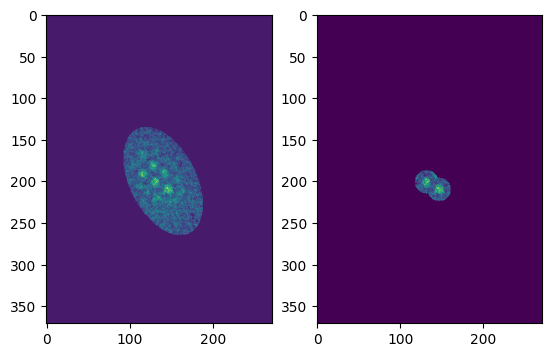

false

In [19]:
close("all")
fig, axs = subplots(1, 2)

axs[1].imshow(ODs_dataset[5])
axs[2].imshow(masked_droplets(ODs_dataset[5], centers_droplets[5], radius_droplets, x_crop, y_crop))

# pygui(true); show()
pygui(false)

In [18]:
Iatoms_drop, Ibkg_drop, Idark_drop = zeros(length(ODs_dataset)), zeros(length(ODs_dataset)), zeros(length(ODs_dataset))

for i in ProgressBar(1:length((imgs_atoms_crop_datasets)))
    Convertion_factor = (0.85 * 0.107 * τ_exp[findfirst(==(intensities_imgs[i]), I_set_value)])
    centers_drops = centers_droplets[i]
    if (i ∉ wrong_shots) & (nbr_droplets[i] > 0)
        Iatoms_drop[i] = sum(masked_droplets(imgs_atoms_crop_datasets[i], centers_droplets[i], radius_droplets, x_crop, y_crop))/(nbr_droplets[i]*N_atoms_per_droplet*Convertion_factor)
        Ibkg_drop[i] = sum(masked_droplets(imgs_bkg_crop_datasets[i], centers_droplets[i], radius_droplets, x_crop, y_crop))/(nbr_droplets[i]*N_atoms_per_droplet*Convertion_factor)
        Idark_drop[i] = sum(masked_droplets(imgs_dark_crop_datasets[i], centers_droplets[i], radius_droplets, x_crop, y_crop))/(nbr_droplets[i]*N_atoms_per_droplet*Convertion_factor)
    end
end

0.0%┣                                              ┫ 0/300 [00:00<00:00, -0s/it]
0.3%┣▏                                         ┫ 1/300 [00:01<Inf:Inf, InfGs/it]
1.7%┣▉                                              ┫ 5/300 [00:01<00:48, 6it/s]
3.0%┣█▍                                            ┫ 9/300 [00:01<00:26, 11it/s]
4.7%┣██                                           ┫ 14/300 [00:01<00:17, 17it/s]
5.7%┣██▌                                          ┫ 17/300 [00:01<00:15, 19it/s]
7.0%┣███▏                                         ┫ 21/300 [00:01<00:12, 23it/s]
8.0%┣███▋                                         ┫ 24/300 [00:01<00:11, 24it/s]
9.3%┣████▏                                        ┫ 28/300 [00:01<00:10, 26it/s]
10.0%┣████▍                                       ┫ 30/300 [00:01<00:10, 27it/s]
11.3%┣█████                                       ┫ 34/300 [00:01<00:09, 29it/s]
12.0%┣█████▎                                      ┫ 36/300 [00:01<00:09, 29it/s]
13.3%┣█████▉                

In [35]:
Iatoms_drop_per_sat, Ibkg_drop_per_sat, Idark_drop_per_sat = zeros((length(sat_exp), Integer(length(Iatoms_drop)/length(sat_exp)))), zeros((length(sat_exp), Integer(length(Iatoms_drop)/length(sat_exp)))), zeros((length(sat_exp), Integer(length(Iatoms_drop)/length(sat_exp))))

for i in 1:length(Iatoms_drop)
    if i ∉ wrong_shots
        idx = findfirst(==(intensities_imgs[i]), I_set_value)
        # println("$i $idx $(floor(Int64, ((i-1)%(Integer(length(Iatoms_drop)/length(sat_exp)))+1)))")
        Iatoms_drop_per_sat[idx, floor(Int64, ((i-1)%(Integer(length(Iatoms_drop)/length(sat_exp)))+1))] = Iatoms_drop[i]
        Ibkg_drop_per_sat[idx, floor(Int64, ((i-1)%(Integer(length(Iatoms_drop)/length(sat_exp)))+1))] = Ibkg_drop[i]
        Idark_drop_per_sat[idx, floor(Int64, ((i-1)%(Integer(length(Iatoms_drop)/length(sat_exp)))+1))] = Idark_drop[i]
    end
end

In [37]:
Mean_Iatoms_per_sat, Mean_Ibkg_per_sat, Mean_Idark_per_sat = [], [], []
Std_Iatoms_per_sat, Std_Ibkg_per_sat, Std_Idark_per_sat = [], [], []
for i = 1:size(Iatoms_drop_per_sat)[1]
    I_atms, I_bkg, I_dark = [], [], []
    for j = 1:size(Iatoms_drop_per_sat)[2]
        if Iatoms_drop_per_sat[i, j] != 0
            push!(I_atms, Iatoms_drop_per_sat[i, j]), push!(I_bkg, Ibkg_drop_per_sat[i, j]), push!(I_dark, Idark_drop_per_sat[i, j])
        end
    end
    if length(I_atms) > 0
        push!(Mean_Iatoms_per_sat, mean(I_atms)), push!(Mean_Ibkg_per_sat, mean(I_bkg)), push!(Mean_Idark_per_sat, mean(I_dark))
        push!(Std_Iatoms_per_sat, std(I_atms)), push!(Std_Ibkg_per_sat, std(I_bkg)), push!(Std_Idark_per_sat, std(I_dark))
    else
        push!(Mean_Iatoms_per_sat, 0), push!(Mean_Ibkg_per_sat, 0), push!(Mean_Idark_per_sat, 0)
        push!(Std_Iatoms_per_sat, 0), push!(Std_Ibkg_per_sat, 0), push!(Std_Idark_per_sat, 0)
    end
end
        

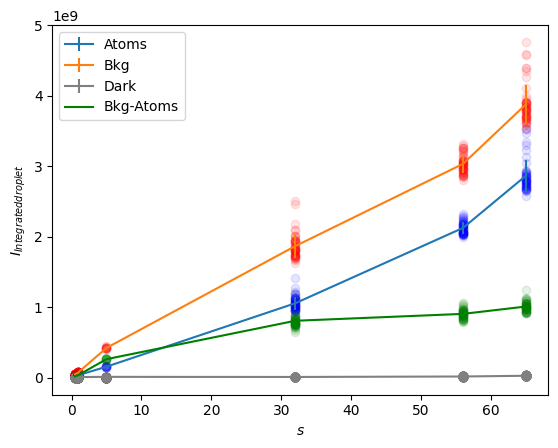

In [38]:
close("all")
fig = subplots()

# errorbar(sat_exp)

errorbar(sat_exp, Mean_Iatoms_per_sat, yerr=Std_Iatoms_per_sat, label="Atoms")
errorbar(sat_exp, Mean_Ibkg_per_sat, yerr=Std_Ibkg_per_sat, label="Bkg")
errorbar(sat_exp, Mean_Idark_per_sat, yerr=Std_Idark_per_sat, label="Dark", color="grey")
errorbar(sat_exp, Mean_Ibkg_per_sat-Mean_Iatoms_per_sat, label="Bkg-Atoms", color="green")

for (i, OD) in enumerate(ODs_dataset)
    scatter(dict_set_val_sat[intensities_imgs[i]], Iatoms_drop[i], color="b", alpha = 0.1)
    scatter(dict_set_val_sat[intensities_imgs[i]], Ibkg_drop[i], color="r", alpha = 0.1)
    scatter(dict_set_val_sat[intensities_imgs[i]], Ibkg_drop[i]-Iatoms_drop[i], color="g", alpha = 0.1)
    scatter(dict_set_val_sat[intensities_imgs[i]], Idark_drop[i], color="grey")
end

xlabel(L"s")
ylabel(L"I_{Integrated droplet}")

legend()

# pygui(true); show();
pygui(false);

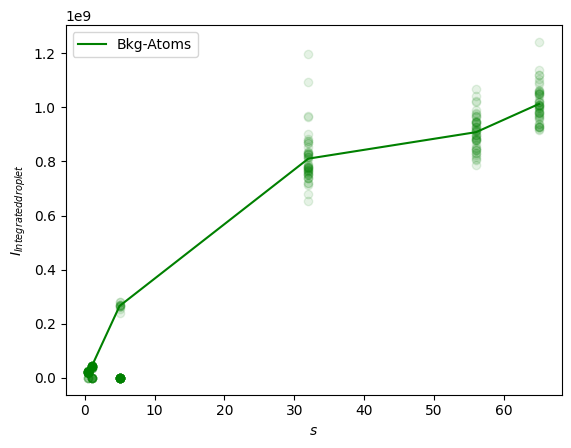

In [39]:
close("all")
fig = subplots()

errorbar(sat_exp, Mean_Ibkg_per_sat-Mean_Iatoms_per_sat, label="Bkg-Atoms", color="green")

for (i, OD) in enumerate(ODs_dataset)
    scatter(dict_set_val_sat[intensities_imgs[i]], Ibkg_drop[i]-Iatoms_drop[i], color="g", alpha = 0.1)
end

xlabel(L"s")
ylabel(L"I_{Integrated droplet}")

legend()

# pygui(true); show();
pygui(false);

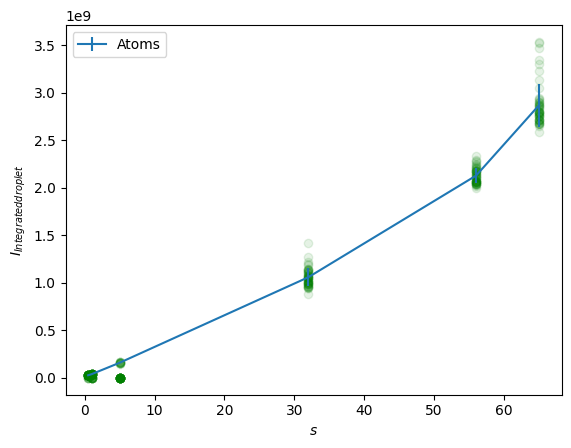

In [40]:
close("all")
fig = subplots()

errorbar(sat_exp, Mean_Iatoms_per_sat, yerr=Std_Iatoms_per_sat, label="Atoms")

for (i, OD) in enumerate(ODs_dataset)
    scatter(dict_set_val_sat[intensities_imgs[i]], Iatoms_drop[i], color="g", alpha = 0.1)
end

xlabel(L"s")
ylabel(L"I_{Integrated droplet}")

# function It(s, sat_exp, Iatoms_drop_per_sat)
#     return mean(Iatoms_drop_per_sat, dims = 2)[end-1]/sat_exp[end-1] .* s
# end

# It_range = It(sat_exp, sat_exp, Iatoms_drop_per_sat)
# plot(sat_exp, It_range, linestyle="--", color="grey", label=L"I_t")

legend()

# pygui(true); show();
pygui(false);

In [41]:
close("all")
fig = subplots()

errorbar(sat_exp, vec(mean(Iatoms_drop_per_sat, dims = 2)) - It_range, yerr=vec(std(Iatoms_drop_per_sat, dims = 2)), label="Atoms", color="green")

for (i, OD) in enumerate(ODs_dataset)
    scatter(dict_set_val_sat[intensities_imgs[i]], Iatoms_drop[i] - It_range[findfirst(==(intensities_imgs[i]), I_set_value)], color="g", alpha = 0.1)
end

xlabel(L"s")
ylabel(L"I_{Integrated droplet}")

legend()

# pygui(true); show();
pygui(false);

LoadError: UndefVarError: `It_range` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

# Brouillons

In [ ]:
# threshold_droplets_range = 8000000
# OD = ODs_dataset[10]
# size_kernel_smooth = 5
# smooth_norm_OD = normalize(smooth_imgs(OD, size_kernel_smooth)) # Normalize to gaussian kernel
# centers, label_blobs = find_droplets_radius_range(smooth_norm_OD, droplet_radius_range, threshold_droplets_range)

# fig, axs = subplots(1, 3, figsize=(10, 5))
# axs[1].imshow(smooth_norm_OD)
# axs[2].imshow(label_blobs)
# axs[2].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r")
# axs[3].imshow(OD)
# axs[3].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r", alpha=0.5)
